In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import utils
import paths as p
import constants as c

In [2]:
qc_dir = p.DATA_DIR / 'qc_metrics'
if not qc_dir.exists():
    os.makedirs(qc_dir)

In [3]:
units_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_all.csv'), index_col=0)

In [4]:
sessions_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_all.csv'), index_col=0)
sessions_all = sessions_all.rename(columns={'id': 'session_id'})

if 'datetime' in sessions_all.columns:
    sessions_all['date'] = pd.to_datetime(sessions_all['datetime']).dt.normalize()

def has_str_and_v1(regions):
    return ('str' in regions.values) and ('v1' in regions.values)

sessions_all['simultaneous'] = sessions_all.groupby(['mouse', 'date'])['region'].transform(has_str_and_v1)

In [5]:
units_all_merged = units_all.merge(
    sessions_all[['session_id', 'mouse', 'insertion_number', 'datetime', 'paramset_idx', 'simultaneous']],
    on='session_id',
    how='left'
)

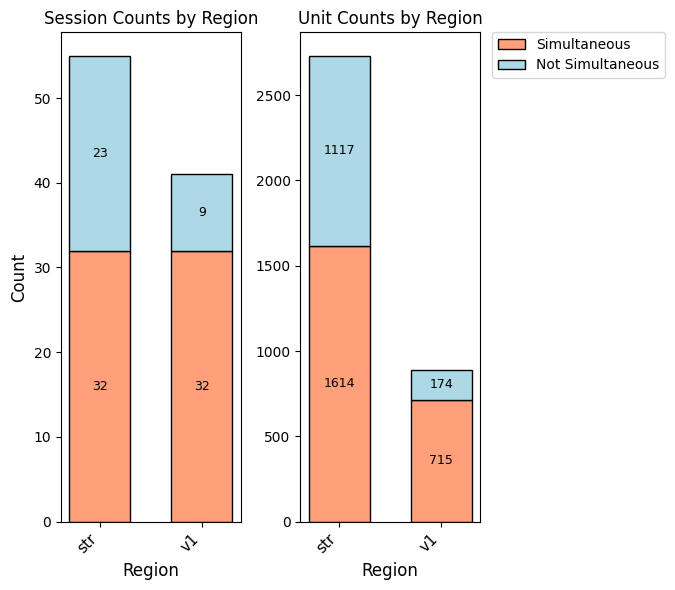

In [6]:
# Sessions subplot
region_simul_counts_sessions = sessions_all.groupby(['region', 'simultaneous']).size().reset_index(name='count')
pivot_sessions = region_simul_counts_sessions.pivot(index='region', columns='simultaneous', values='count').fillna(0)
pivot_sessions = pivot_sessions.reindex(columns=[True, False], fill_value=0)

# Units subplot
region_simul_counts_units = units_all_merged.groupby(['region', 'simultaneous']).size().reset_index(name='count')
pivot_units = region_simul_counts_units.pivot(index='region', columns='simultaneous', values='count').fillna(0)
pivot_units = pivot_units.reindex(columns=[True, False], fill_value=0)


x = np.arange(len(pivot_sessions.index))
bar_width = 0.6

fig, axs = plt.subplots(1, 2, figsize=(5, 6))

# Sessions plot
bars_sess_simul = axs[0].bar(x, pivot_sessions[True], width=bar_width, label='Simultaneous', color='lightsalmon', edgecolor='black')
bars_sess_nonsimul = axs[0].bar(x, pivot_sessions[False], width=bar_width, bottom=pivot_sessions[True], label='Not Simultaneous', color='lightblue', edgecolor='black')
axs[0].set_xticks(x)
axs[0].set_xticklabels(pivot_sessions.index, rotation=45, ha='right', fontsize=11)
axs[0].set_title('Session Counts by Region')
axs[0].set_ylabel('Count', fontsize=12)
axs[0].set_xlabel('Region', fontsize=12)
# Value labels
for bar in bars_sess_simul + bars_sess_nonsimul:
    height = bar.get_height()
    if height > 0:
        axs[0].text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                    ha='center', va='center', fontsize=9, color='black')

# Units plot
bars_units_simul = axs[1].bar(x, pivot_units[True], width=bar_width, label='Simultaneous', color='lightsalmon', edgecolor='black')
bars_units_nonsimul = axs[1].bar(x, pivot_units[False], width=bar_width, bottom=pivot_units[True], label='Not Simultaneous', color='lightblue', edgecolor='black')
axs[1].set_xticks(x)
axs[1].set_xticklabels(pivot_units.index, rotation=45, ha='right', fontsize=11)
axs[1].set_title('Unit Counts by Region')
axs[1].set_xlabel('Region', fontsize=12)
# Value labels
for bar in bars_units_simul + bars_units_nonsimul:
    height = bar.get_height()
    if height > 0:
        axs[1].text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                    ha='center', va='center', fontsize=9, color='black')

# Add one legend to the right of the plots
handles, labels = axs[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.9))

plt.tight_layout()
plt.savefig(os.path.join(p.FIGURES_DIR, 'region_simultaneous_counts.png'), dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print("Summary Statistics:")
print("total sessions:", len(sessions_all))
print("num str sessions:", pivot_sessions.loc['str'].sum())
print("num v1 sessions:", pivot_sessions.loc['v1'].sum())
print("simultaneous sessions:", pivot_sessions.loc['str', True])
print()
print("total units:", len(units_all_merged))
print("num str units:", pivot_units.loc['str'].sum())
print("num v1 units:", pivot_units.loc['v1'].sum())

Summary Statistics:
total sessions: 96
num str sessions: 55
num v1 sessions: 41
simultaneous sessions: 32

total units: 3620
num str units: 2731
num v1 units: 889


# QC

In [8]:
units_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'), index_col=0)
units_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_all.csv'), index_col=0)

In [9]:
units_merged = units_all.merge(
    sessions_all[['session_id', 'mouse', 'insertion_number', 'datetime', 'paramset_idx', 'simultaneous']],
    on='session_id',
    how='left'
)

In [10]:
# qc_df = pd.read_csv(os.path.join(p.LOGS_DIR, 'RZ_quality_metrics.csv'), index_col=0)
qc_df = pd.read_csv(os.path.join(p.LOGS_DIR, 'RZ_quality_metrics.csv'))
qc_df = qc_df.rename(columns={'subject': 'mouse', 'unit':'id', 'session_datetime':'datetime'})

In [11]:
# Merge qc_df info into units_all_merged based on the specified columns
cols = ['mouse', 'datetime', 'insertion_number', 'paramset_idx', 'id']

units_with_qc = units_merged.merge(
    qc_df,
    on=cols,
    how='left',
    suffixes=('', '_qc')
)

In [12]:
df = units_with_qc.copy()

qc_thresholds = c.QC_THRESHOLDS
qc_thresholds_secondary = c.QC_THRESHOLDS_SECONDARY

In [13]:
def hist_plot(series, title, bins=50, filename=None, xlim=None, qc_threshold=None):
    plt.figure(figsize=(8, 5), dpi=140)
    sns.histplot(series.dropna(), bins=bins, color='cornflowerblue', edgecolor='black')
    plt.title(title)
    plt.ylabel("Count")
    # Add shading for "kept" region
    if qc_threshold is not None:
        op = qc_threshold[0]
        threshold = qc_threshold[1]
        if op == ">":
            plt.axvspan(threshold, plt.xlim()[1], color='skyblue', alpha=0.18, label='Kept region')
        elif op == "<":
            plt.axvspan(plt.xlim()[0], threshold, color='skyblue', alpha=0.18, label='Kept region')
        plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold}')
        plt.legend()
    if xlim is not None:
        plt.xlim(*xlim)
    plt.tight_layout()
    if filename:
        plt.savefig(qc_dir / filename, bbox_inches="tight")
    plt.show()

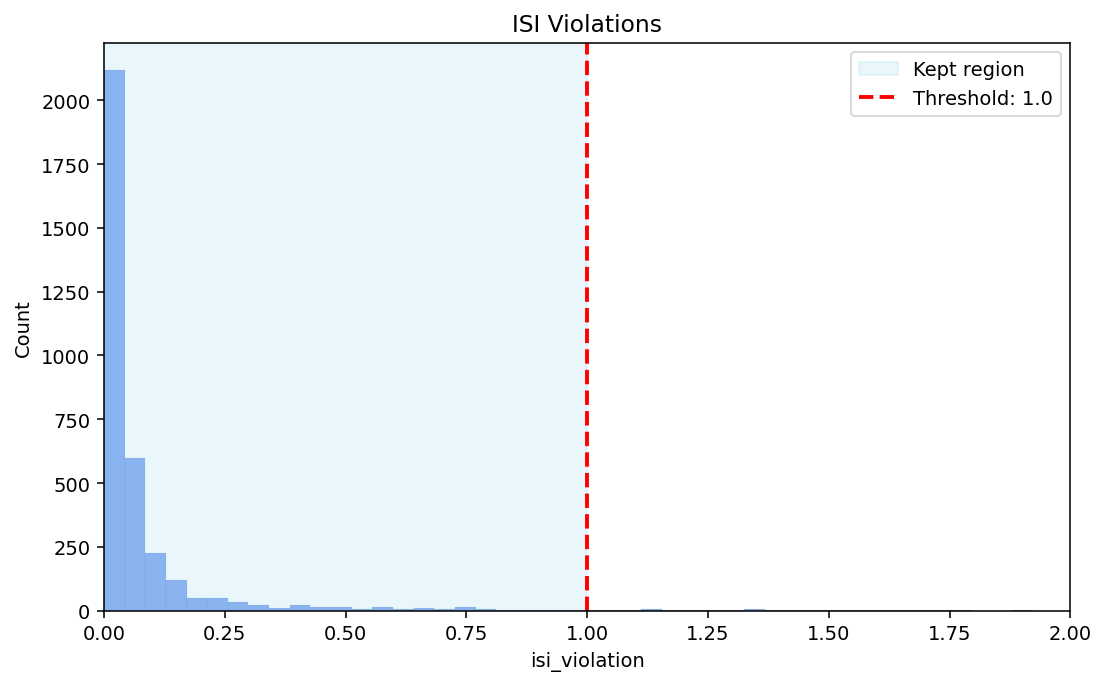

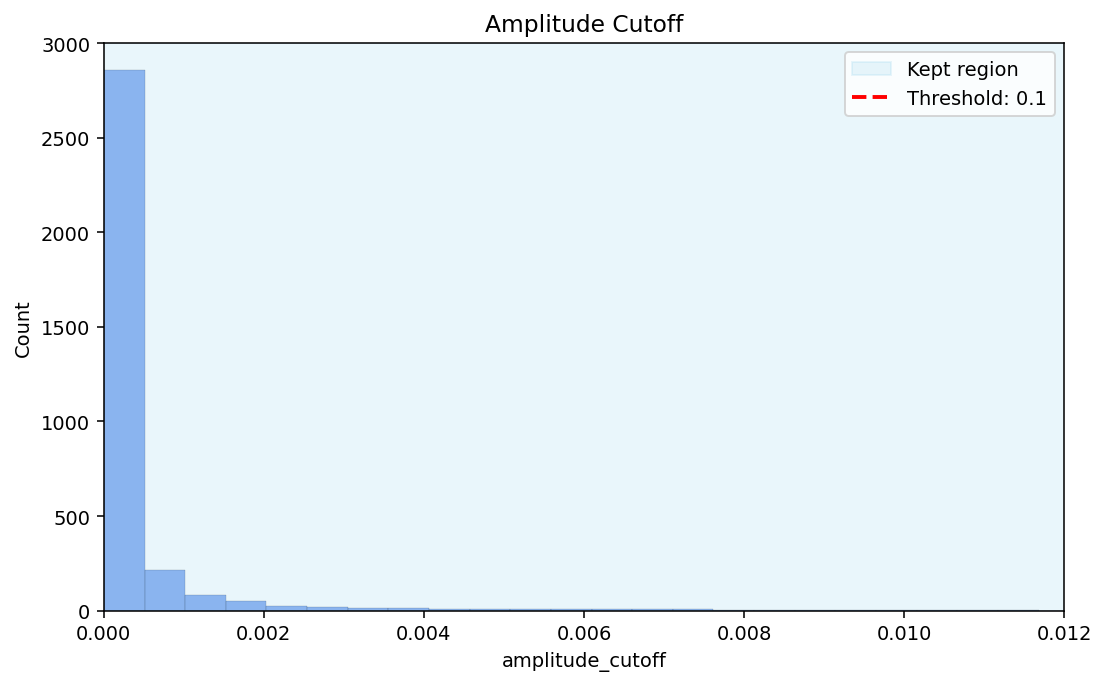

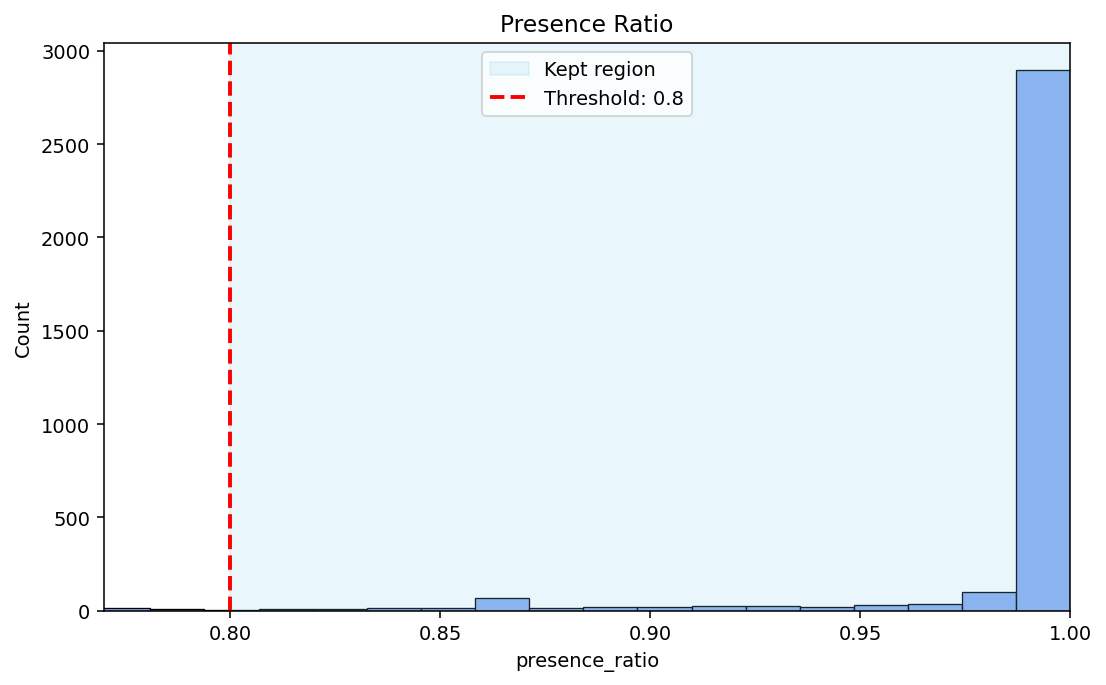

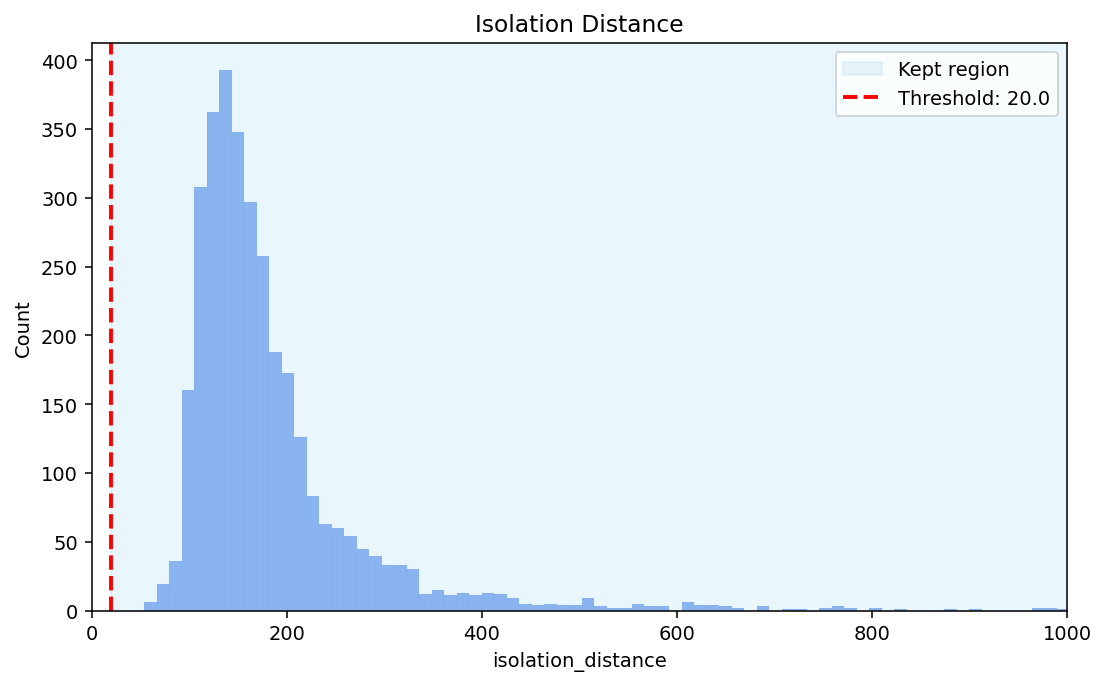

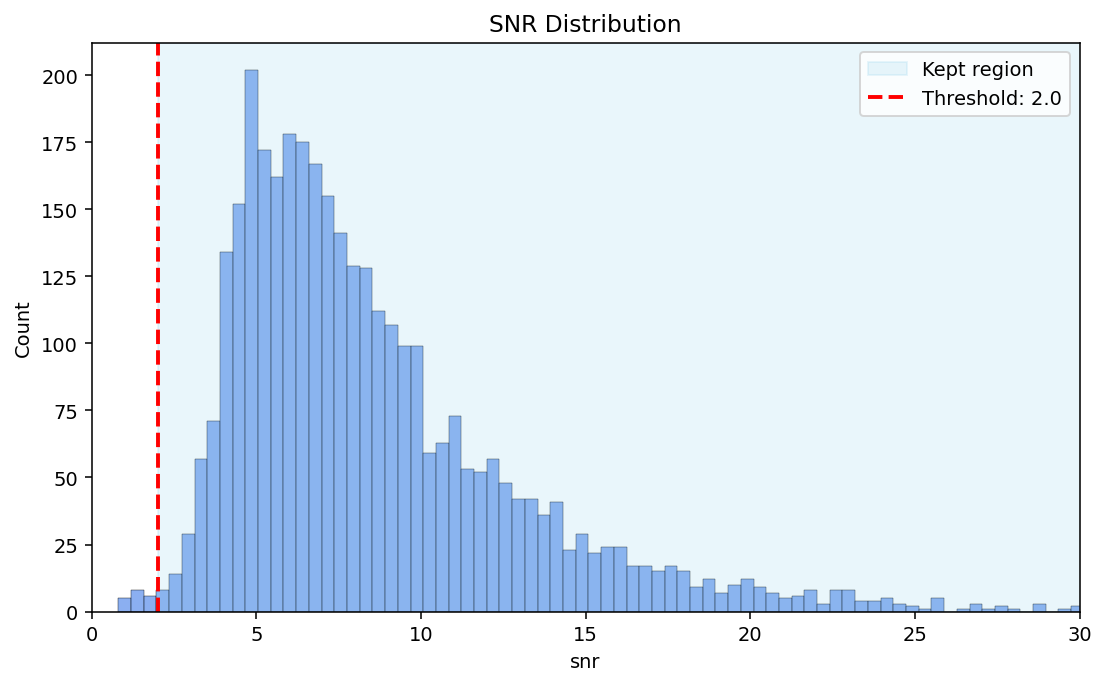

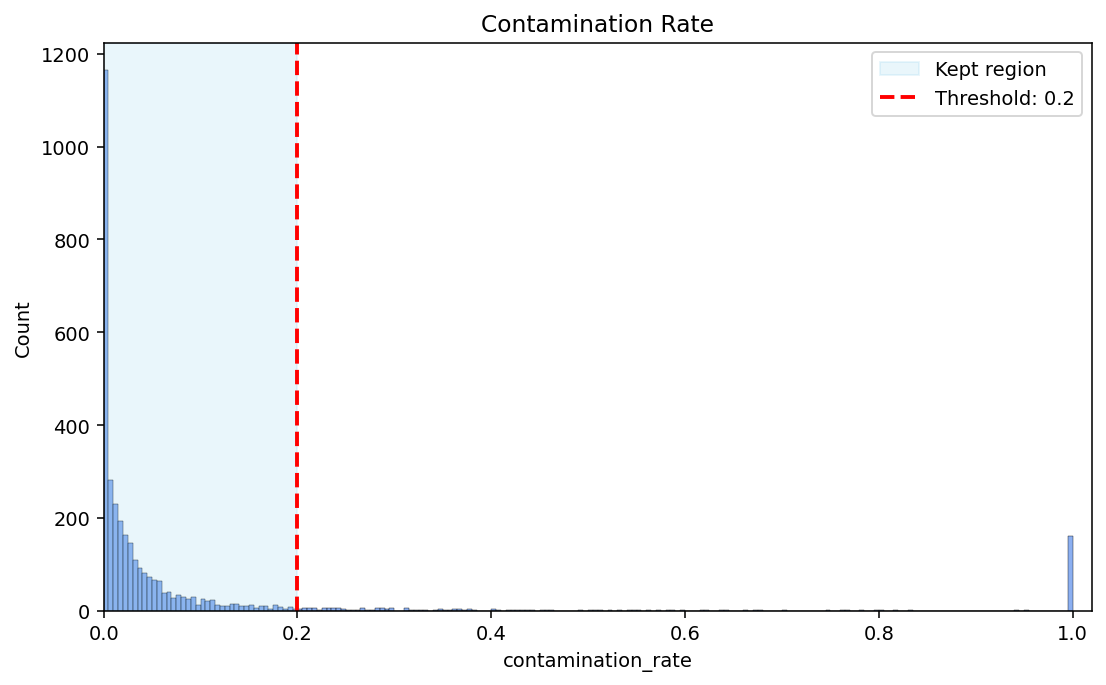

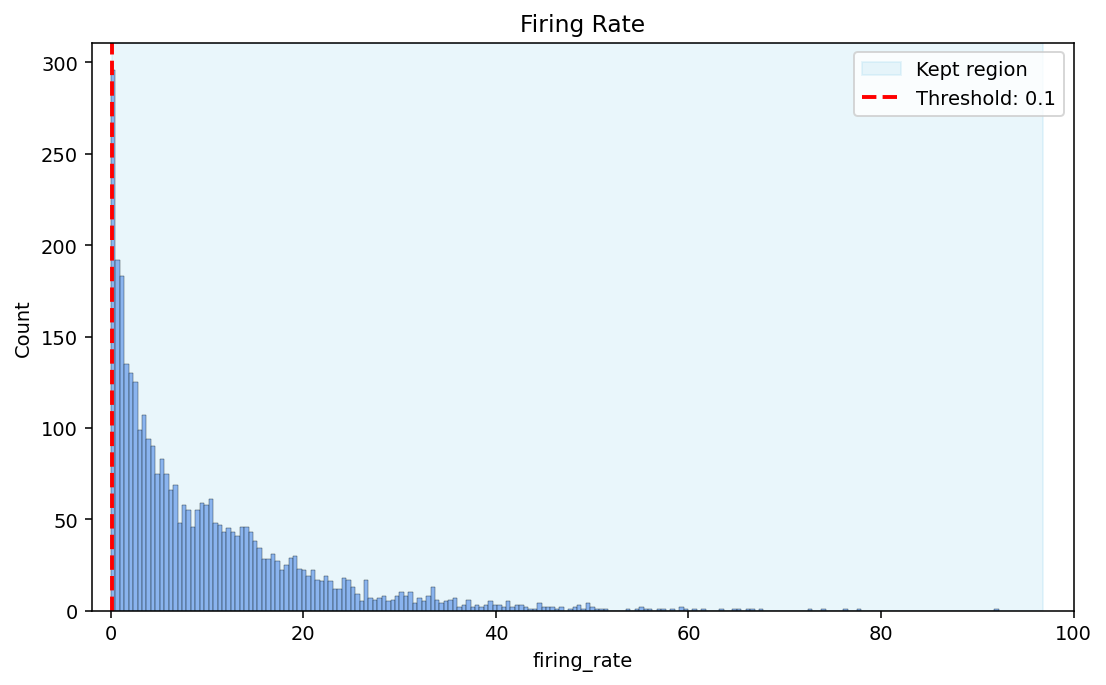

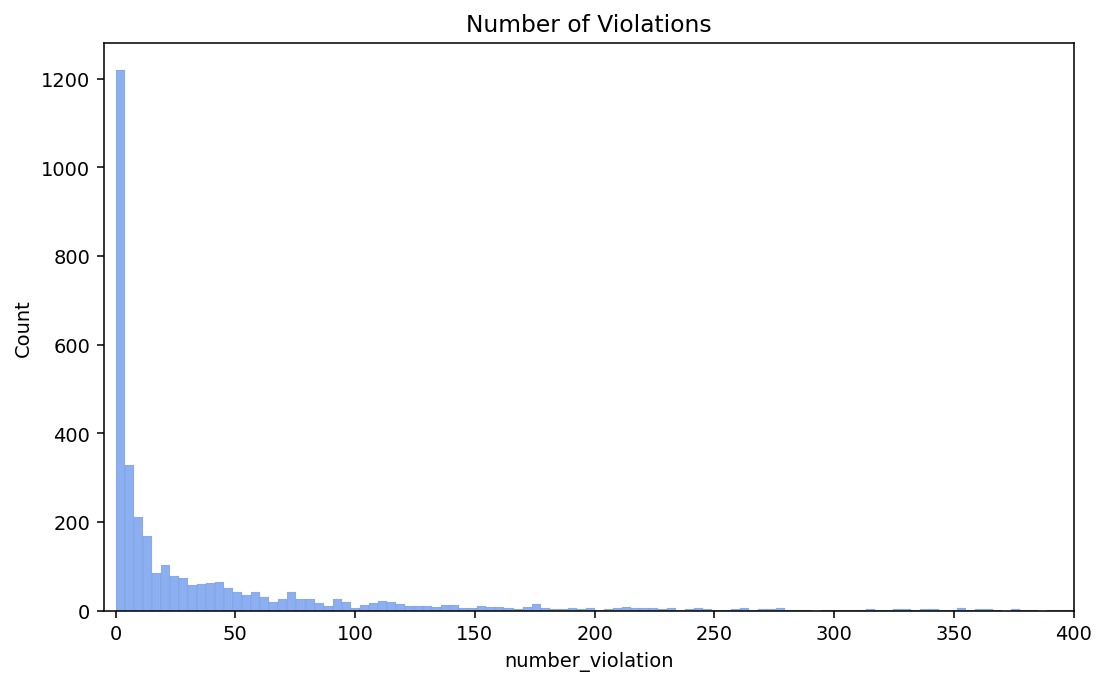

In [14]:
# Primary QC metrics
METRIC_PLOT_CONFIG = {
    "isi_violation":      {"title": "ISI Violations",       "bins": 2000, "xlim": (0, 2)},
    "amplitude_cutoff":   {"title": "Amplitude Cutoff",     "bins": 500,  "xlim": (0, 0.012)},
    "presence_ratio":     {"title": "Presence Ratio",       "bins": 60,   "xlim": (0.77, 1.0)},
    "isolation_distance": {"title": "Isolation Distance",   "bins": 5000, "xlim": (0, 1000)},
    "snr":                {"title": "SNR Distribution",     "bins": 200,  "xlim": (0, 30)},
    "contamination_rate": {"title": "Contamination Rate",   "bins": 200,  "xlim": (0, 1.02)},
    "firing_rate":        {"title": "Firing Rate",          "bins": 200,  "xlim": (-2, 100)},
    "number_violation":   {"title": "Number of Violations", "bins": 2000, "xlim": (-5, 400)},
}

for metric, cfg in METRIC_PLOT_CONFIG.items():
    thresh = qc_thresholds.get(metric)
    hist_plot(df[metric], cfg["title"], bins=cfg["bins"],
              filename=f"hist_{metric}.png", xlim=cfg["xlim"],
              qc_threshold=thresh)

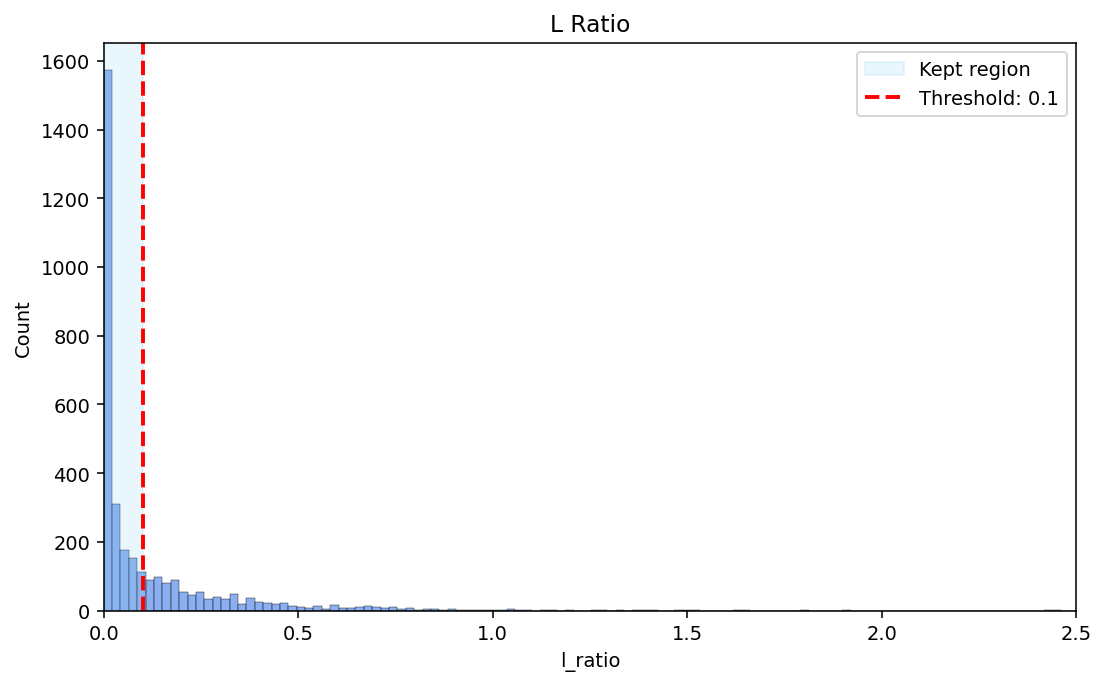

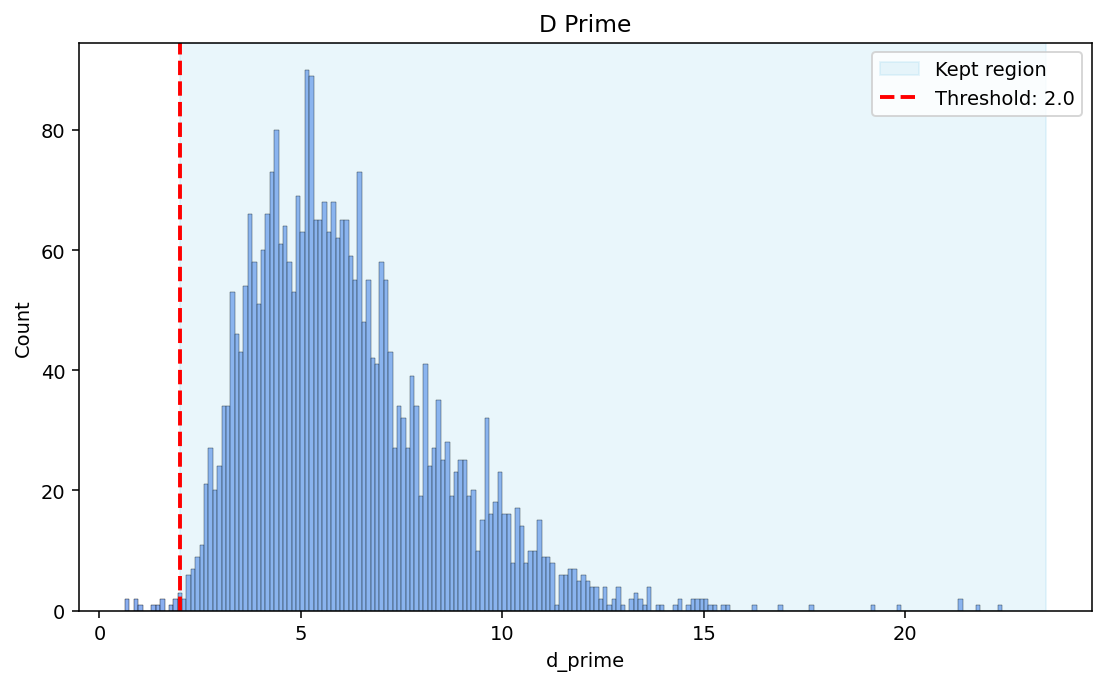

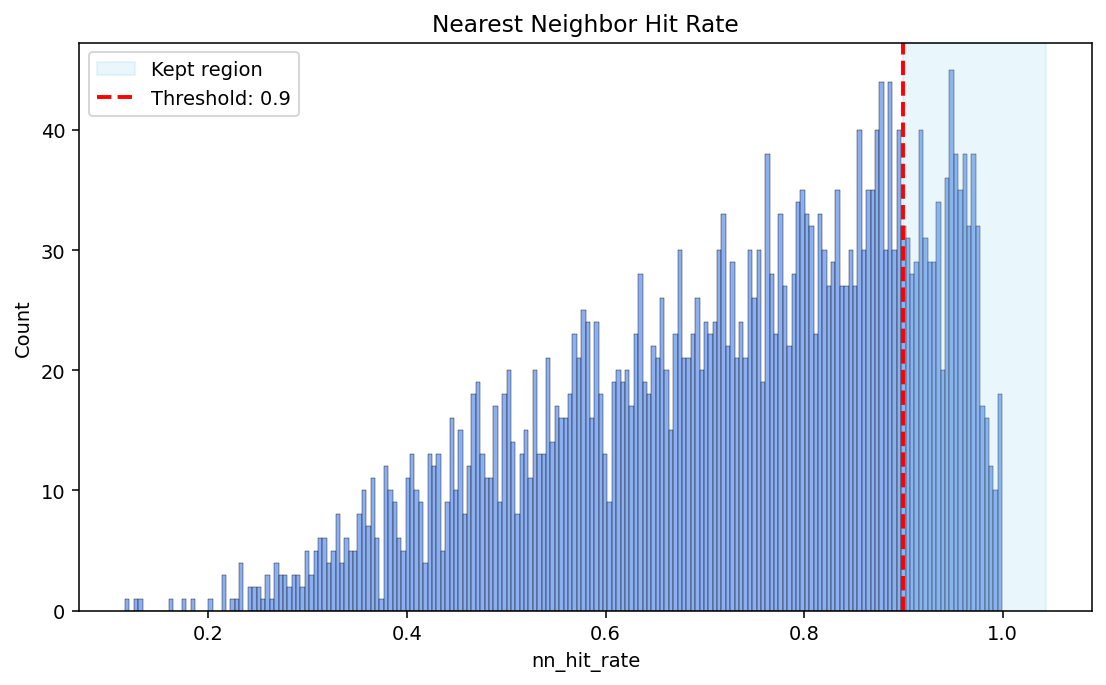

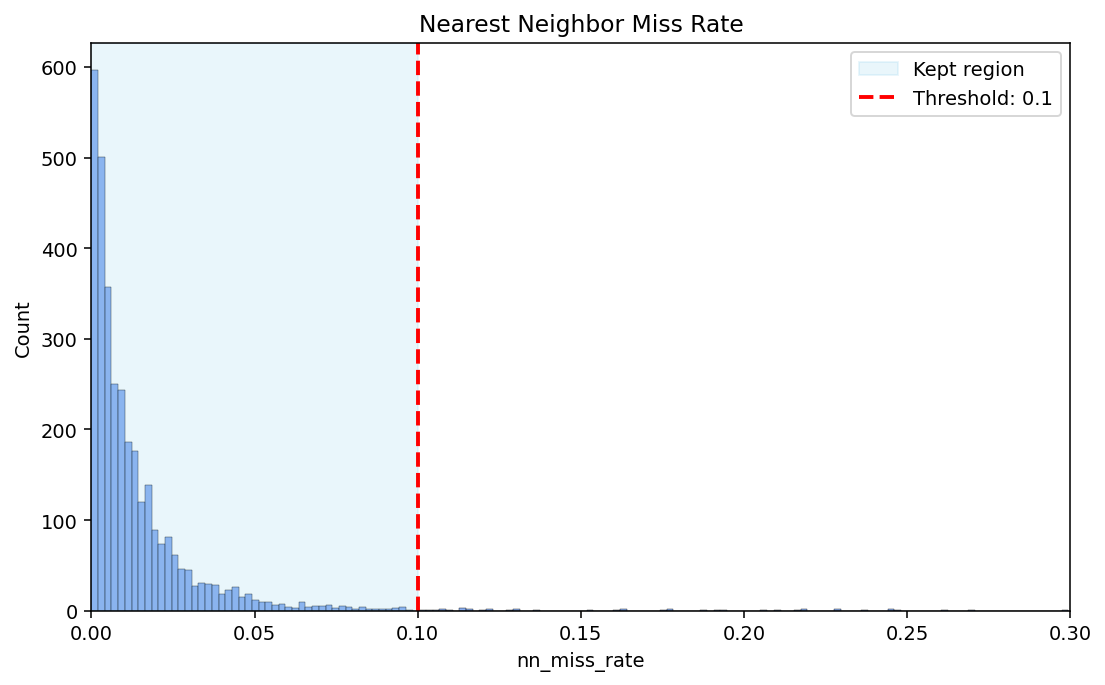

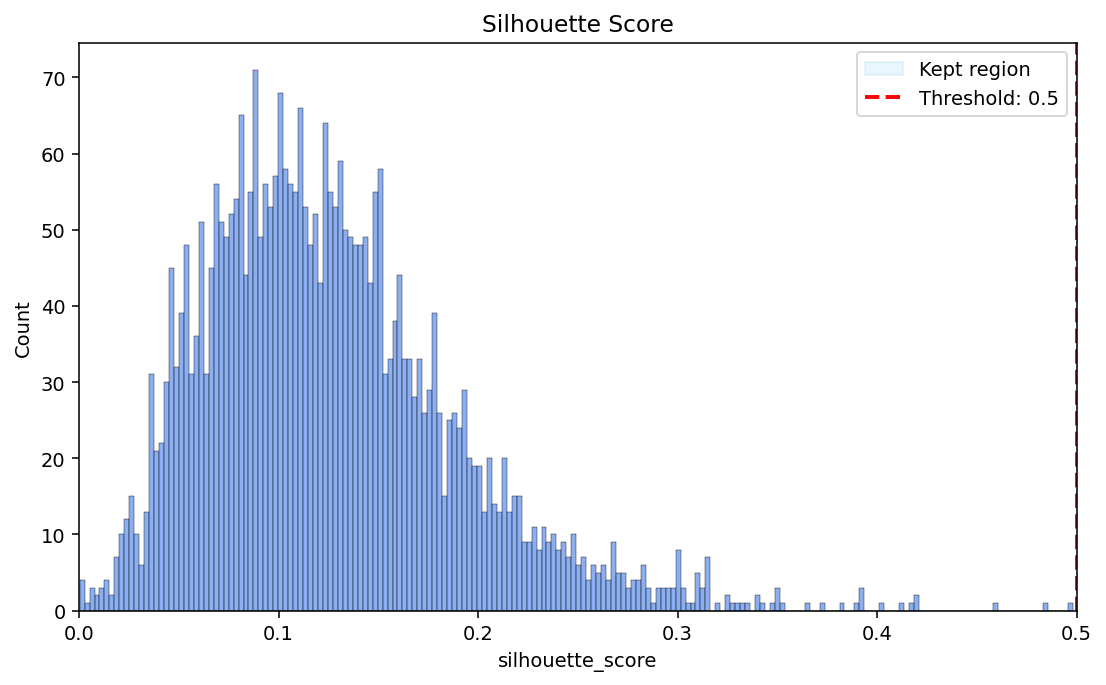

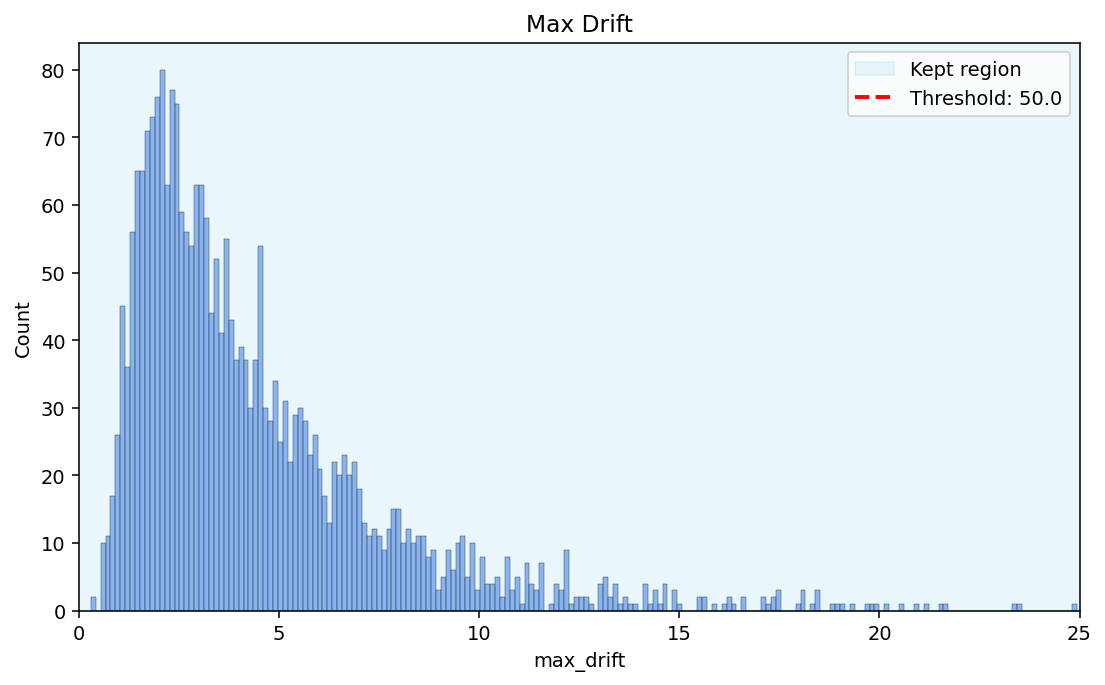

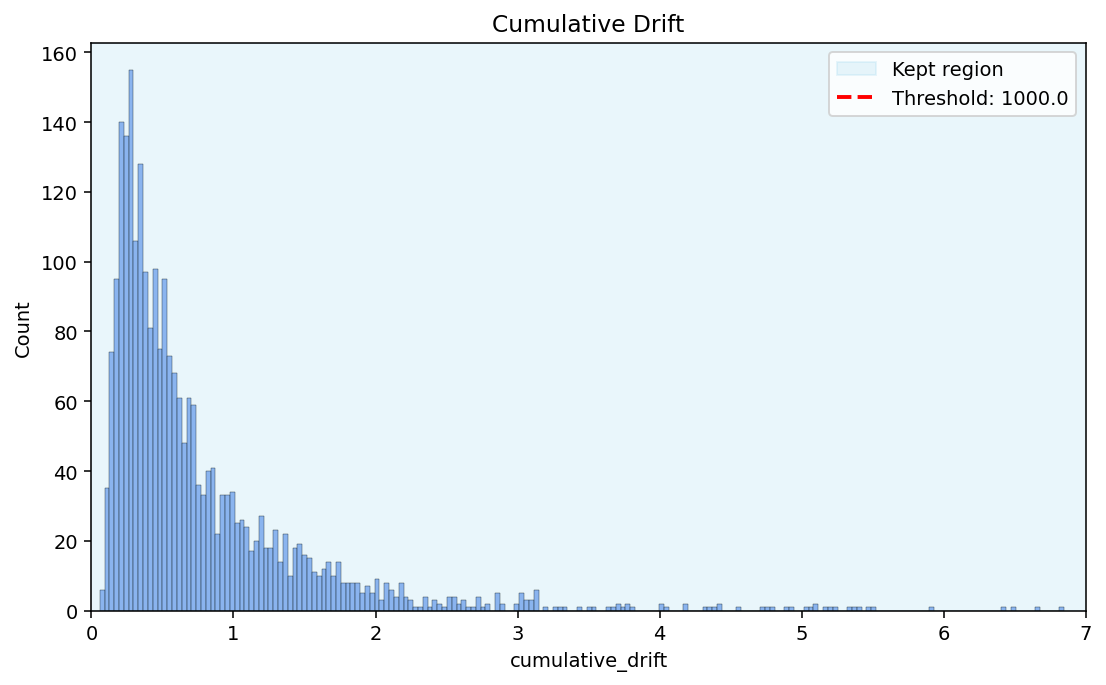

In [15]:
# Secondary QC metrics
METRIC_PLOT_CONFIG_SECONDARY = {
    "l_ratio":          {"title": "L Ratio",                    "bins": 200, "xlim": (0, 2.5)},
    "d_prime":          {"title": "D Prime",                    "bins": 200, "xlim": None},
    "nn_hit_rate":      {"title": "Nearest Neighbor Hit Rate",  "bins": 200, "xlim": None},
    "nn_miss_rate":     {"title": "Nearest Neighbor Miss Rate", "bins": 200, "xlim": (0, 0.3)},
    "silhouette_score": {"title": "Silhouette Score",           "bins": 200, "xlim": (0, 0.5)},
    "max_drift":        {"title": "Max Drift",                  "bins": 200, "xlim": (0, 25)},
    "cumulative_drift": {"title": "Cumulative Drift",           "bins": 200, "xlim": (0, 7)},
}

for metric, cfg in METRIC_PLOT_CONFIG_SECONDARY.items():
    thresh = qc_thresholds_secondary.get(metric)
    hist_plot(df[metric], cfg["title"], bins=cfg["bins"],
              filename=f"hist_{metric}.png", xlim=cfg["xlim"],
              qc_threshold=thresh)

In [16]:
def apply_rule(series: pd.Series, op: str, val: float) -> pd.Series:
    ops = {"<": series.__lt__, "<=": series.__le__,
           ">": series.__gt__, ">=": series.__ge__, "==": series.__eq__}
    return ops.get(op, lambda v: pd.Series(False, index=series.index))(val)

def compute_qc_summary(df, groupby_col):
    summary = (
        df.groupby(groupby_col, dropna=False)
          .agg(total_units=("unit_id", "count"),
               qc_pass_units=("qc_pass_all", "sum"))
          .reset_index()
    )
    summary["qc_pass_pct"] = 100.0 * summary["qc_pass_units"] / summary["total_units"]
    return summary

In [17]:
qc_mask_parts = []
for metric, (op, val) in qc_thresholds.items():
    if metric in df.columns:
        m = apply_rule(df[metric], op, val)
        qc_mask_parts.append(m.fillna(False))
        df[f"qc_pass_{metric}"] = m
    else:
        df[f"qc_pass_{metric}"] = False

df["qc_pass_all"] = np.logical_and.reduce(qc_mask_parts) if qc_mask_parts else False

# Summaries
group_key = "session_id" if df["session_id"].notna().any() else "datetime"
summary_overall = pd.DataFrame({
    "total_units": [len(df)],
    "qc_pass_units": [int(df["qc_pass_all"].sum())],
    "qc_pass_pct": [float(100.0 * df["qc_pass_all"].mean())],
})
summary_by_session = compute_qc_summary(df, group_key)
summary_by_region = compute_qc_summary(df, "region")

summary_overall.to_csv(qc_dir / "qc_summary_overall.csv", index=False)
summary_by_session.to_csv(qc_dir / "qc_summary_by_session.csv", index=False)
summary_by_region.to_csv(qc_dir / "qc_summary_by_region.csv", index=False)

display(summary_overall)
display(summary_by_session.sort_values("qc_pass_pct", ascending=False))
display(summary_by_region.sort_values("qc_pass_pct", ascending=False))

,total_units,qc_pass_units,qc_pass_pct
0,3620,2844,78.563536


,session_id,total_units,qc_pass_units,qc_pass_pct
27,RZ050_2024-11-21_v1,2,2,100.000000
41,RZ055_2024-10-30_str,6,6,100.000000
40,RZ053_2024-10-25_v1,4,4,100.000000
33,RZ051_2024-11-21_str,13,13,100.000000
29,RZ050_2024-11-22_v1,3,3,100.000000
...,...,...,...,...
56,RZ058_2025-03-13_v1,9,1,11.111111
54,RZ058_2025-03-12_v1,20,2,10.000000
10,RZ038_2024-07-17_v1,2,0,0.000000
34,RZ051_2024-11-21_v1,3,0,0.000000


,region,total_units,qc_pass_units,qc_pass_pct
0,str,2731,2286,83.705602
1,v1,889,558,62.767154


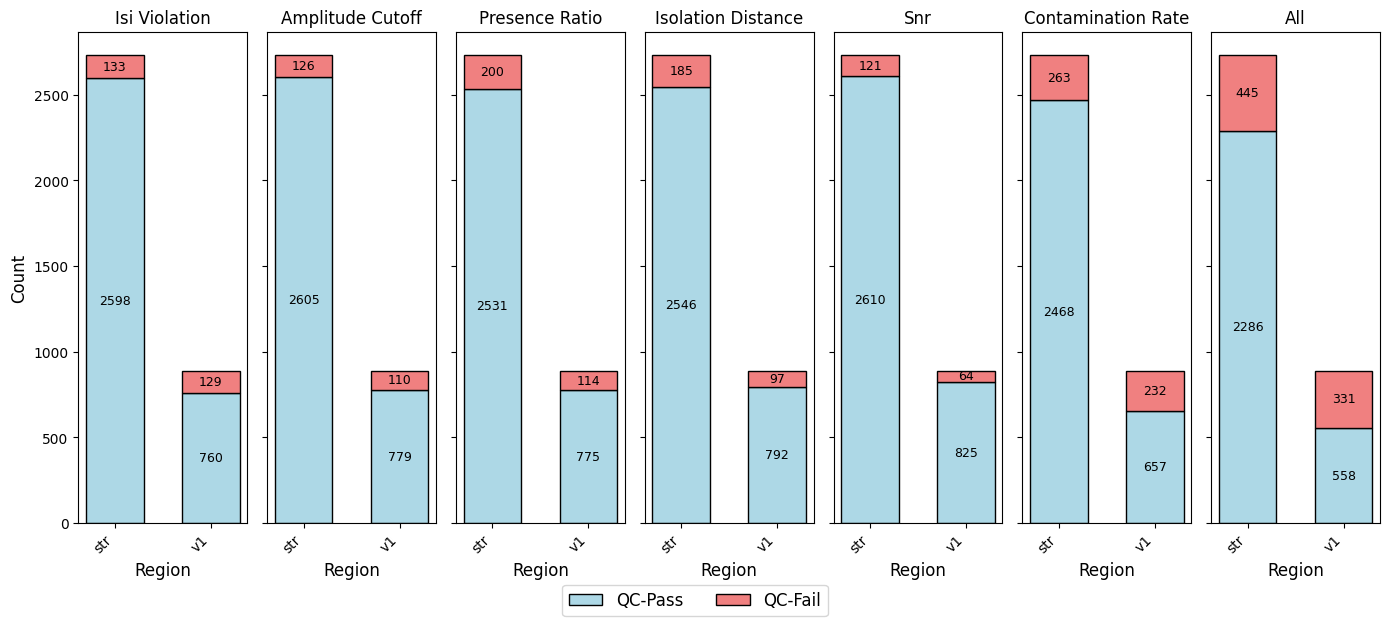

In [18]:
qc_metrics = [
    'qc_pass_isi_violation',
    'qc_pass_amplitude_cutoff',
    'qc_pass_presence_ratio',
    'qc_pass_isolation_distance',
    'qc_pass_snr',
    'qc_pass_contamination_rate',
    'qc_pass_all'
]

fig, axs = plt.subplots(1, len(qc_metrics), figsize=(2 * len(qc_metrics), 6), sharey=True)

for i, metric in enumerate(qc_metrics):
    region_qc_counts = df.groupby(['region', metric]).size().reset_index(name='count')
    pivot_qc = region_qc_counts.pivot(index='region', columns=metric, values='count').fillna(0)
    pivot_qc = pivot_qc.reindex(columns=[True, False], fill_value=0)
    x = np.arange(len(pivot_qc.index))
    bars_pass = axs[i].bar(x, pivot_qc[True], width=0.6, label='QC-Pass', color='lightblue', edgecolor='black')
    bars_fail = axs[i].bar(x, pivot_qc[False], width=0.6, bottom=pivot_qc[True], label='QC-Fail', color='lightcoral', edgecolor='black')
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(pivot_qc.index, rotation=45, ha='right', fontsize=10)
    axs[i].set_title(metric.replace('qc_pass_', '').replace('_', ' ').title())
    axs[i].set_xlabel('Region', fontsize=12)
    # Add value labels
    for bar in bars_pass + bars_fail:
        height = bar.get_height()
        if height > 0:
            axs[i].text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                        ha='center', va='center', fontsize=9, color='black')
    if i == 0:
        axs[i].set_ylabel('Count', fontsize=12)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(qc_dir, 'region_qc_metrics_counts.png'), dpi=300, bbox_inches='tight')

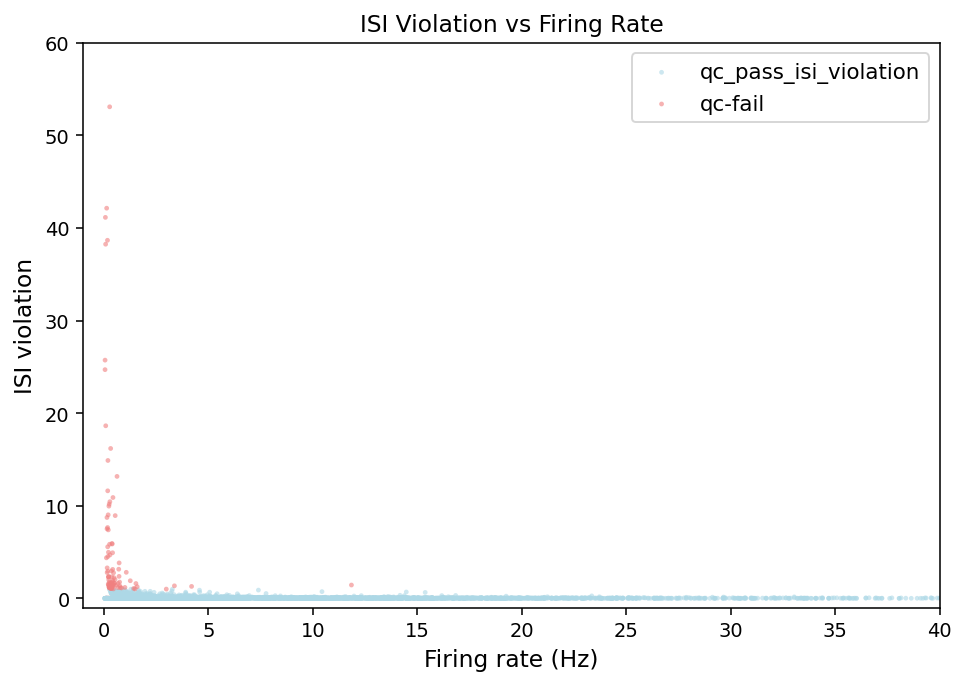

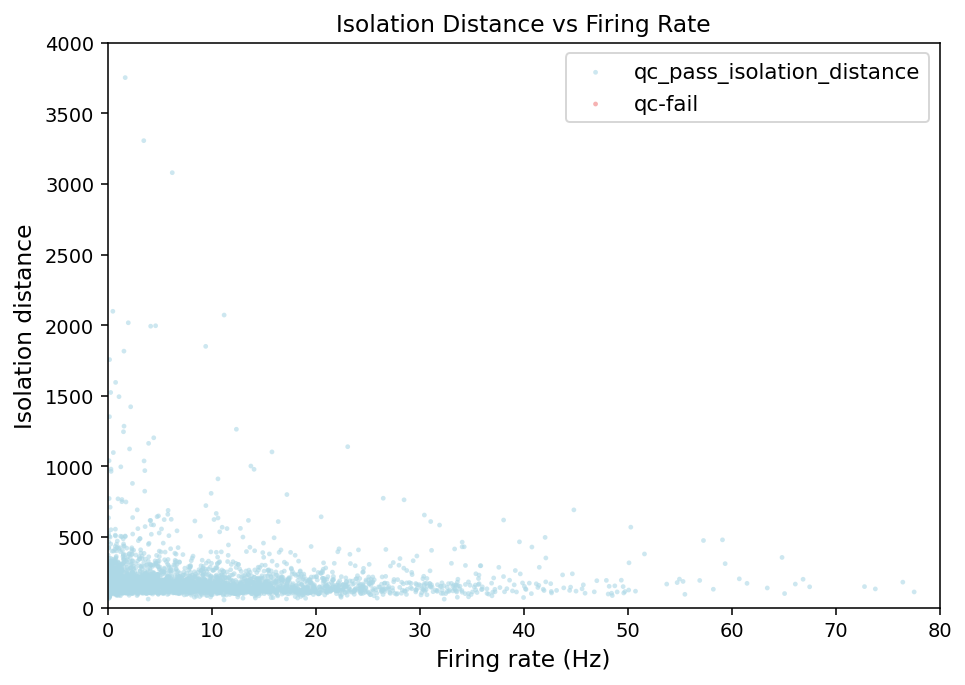

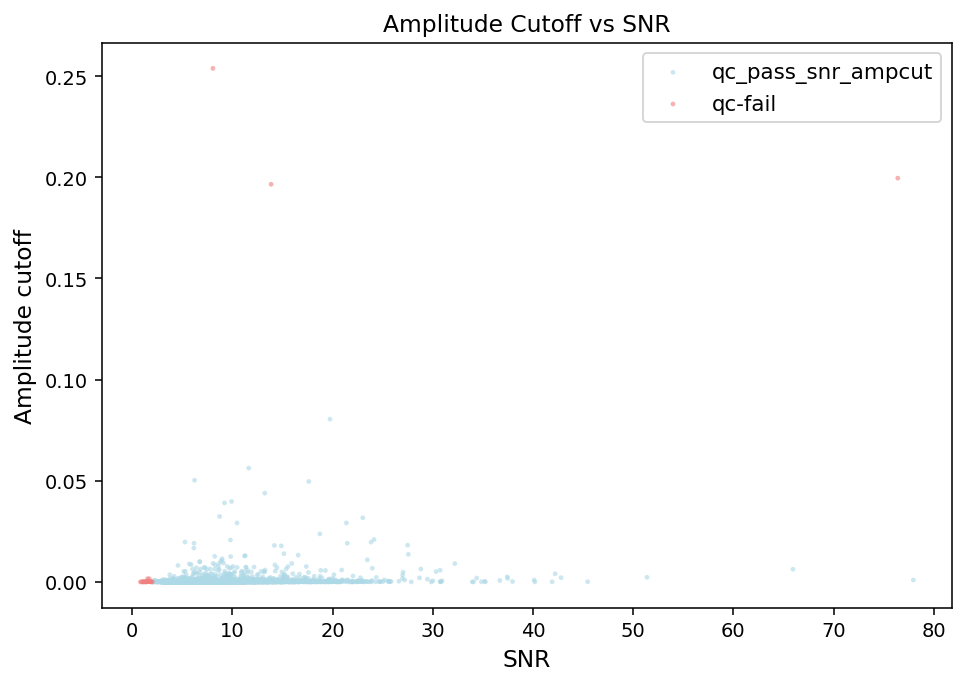

In [19]:
def scatter_plot(df, x_col, y_col, qc_pass_col, title, xlabel, ylabel, alpha=0.6, filename=None, xlim=None, ylim=None):
    x = df[x_col]
    y = df[y_col]
    qc_pass = df[qc_pass_col]
    mask = ~(np.isnan(x.values) | np.isnan(y.values) | pd.isnull(qc_pass.values))
    xclean = x.values[mask]
    yclean = y.values[mask]
    qc_clean = qc_pass.values[mask]

    plt.figure(figsize=(7, 5), dpi=140)
    for val, color, label in zip([True, False], ['lightblue', 'lightcoral'], [qc_pass_col, 'qc-fail']):
        idx = qc_clean == val
        plt.scatter(xclean[idx], yclean[idx], alpha=alpha, s=6, color=color, label=label, edgecolor='none')
    plt.title(title)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(fontsize=11)
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    if filename:
        plt.savefig(qc_dir / filename, bbox_inches="tight")
    plt.show()

# Usage examples:
scatter_plot(df, "firing_rate", "isi_violation", "qc_pass_isi_violation",
             "ISI Violation vs Firing Rate", "Firing rate (Hz)", "ISI violation",
             filename="scat_fr_vs_isi.png",
             xlim=(-1, 40), ylim=(-1, 60))

scatter_plot(df, "firing_rate", "isolation_distance", "qc_pass_isolation_distance",
             "Isolation Distance vs Firing Rate", "Firing rate (Hz)", "Isolation distance",
             filename="scat_fr_vs_iso.png",
             xlim=(0, 80), ylim=(0, 4000))

df["qc_pass_snr_ampcut"] = df["qc_pass_snr"] & df["qc_pass_amplitude_cutoff"]
scatter_plot(df, "snr", "amplitude_cutoff", "qc_pass_snr_ampcut",
             "Amplitude Cutoff vs SNR", "SNR", "Amplitude cutoff",
             filename="scat_snr_vs_ampcut.png")

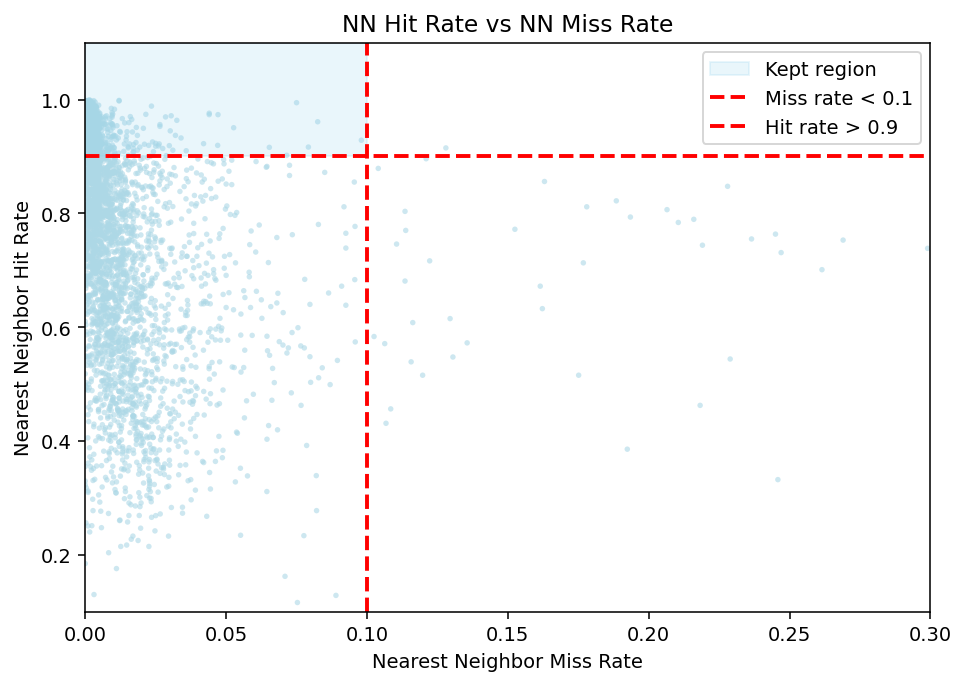

In [20]:
plt.figure(figsize=(7, 5), dpi=140)
plt.scatter(df['nn_miss_rate'], df['nn_hit_rate'], alpha=0.6, s=8, color='lightblue', edgecolor='none')

miss_thresh = qc_thresholds_secondary["nn_miss_rate"][1]  # < 0.2
hit_thresh = qc_thresholds_secondary["nn_hit_rate"][1]    # > 0.8

xlim = plt.xlim(0, 0.3)
ylim = plt.ylim(0.1, 1.1)
x = np.linspace(xlim[0], miss_thresh, 100)
plt.fill_between(x, hit_thresh, ylim[1], color='skyblue', alpha=0.18, label='Kept region')

plt.axvline(miss_thresh, color='red', linestyle='--', linewidth=2, label=f'Miss rate < {miss_thresh}')
plt.axhline(hit_thresh, color='red', linestyle='--', linewidth=2, label=f'Hit rate > {hit_thresh}')
plt.xlabel("Nearest Neighbor Miss Rate")
plt.ylabel("Nearest Neighbor Hit Rate")
plt.title("NN Hit Rate vs NN Miss Rate")
plt.legend()
plt.tight_layout()
plt.savefig(qc_dir / "scat_nn_hit_vs_miss.png", bbox_inches="tight")
# plt.show()

In [21]:
df = df.merge(
        sessions_all[['session_id', 'length']],
        on='session_id',
        how='left'
    )

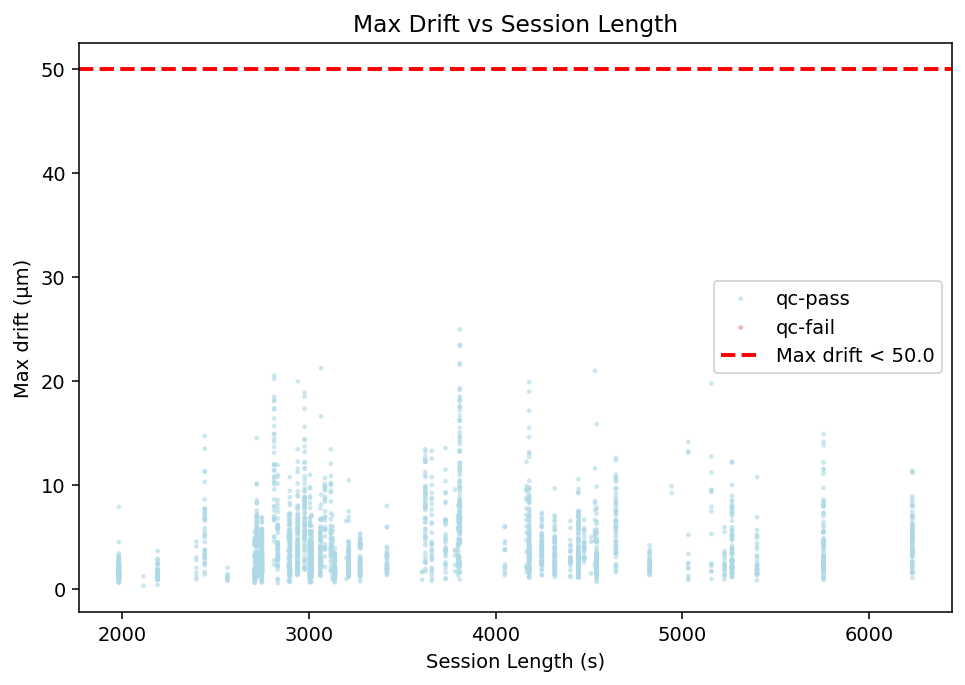

In [22]:
x = df["length"]
y = df["max_drift"]

# Define QC mask
df['qc_pass_max_drift'] = (
    (df['firing_rate'] > qc_thresholds["firing_rate"][1]) &
    (df['max_drift'] < qc_thresholds_secondary["max_drift"][1])
)
qc_pass_max_drift = df['qc_pass_max_drift']

mask = ~(np.isnan(x.values) | np.isnan(y.values))
xclean = x.values[mask]
yclean = y.values[mask]
qc_clean = qc_pass_max_drift.values[mask]

plt.figure(figsize=(7, 5), dpi=140)
plt.scatter(xclean[qc_clean], yclean[qc_clean], alpha=0.6, s=6, color='lightblue', label='qc-pass', edgecolor='none')
plt.scatter(xclean[~qc_clean], yclean[~qc_clean], alpha=0.6, s=6, color='lightcoral', label='qc-fail', edgecolor='none')

fr_thresh = qc_thresholds["firing_rate"][1]
drift_thresh = qc_thresholds_secondary["max_drift"][1]
plt.axhline(drift_thresh, color='red', linestyle='--', linewidth=2, label=f'Max drift < {drift_thresh}')

plt.title("Max Drift vs Session Length")
plt.xlabel("Session Length (s)")
plt.ylabel("Max drift (µm)")
plt.legend()
plt.tight_layout()
plt.savefig(qc_dir / "scat_session_length_vs_maxdrift.png", bbox_inches="tight")

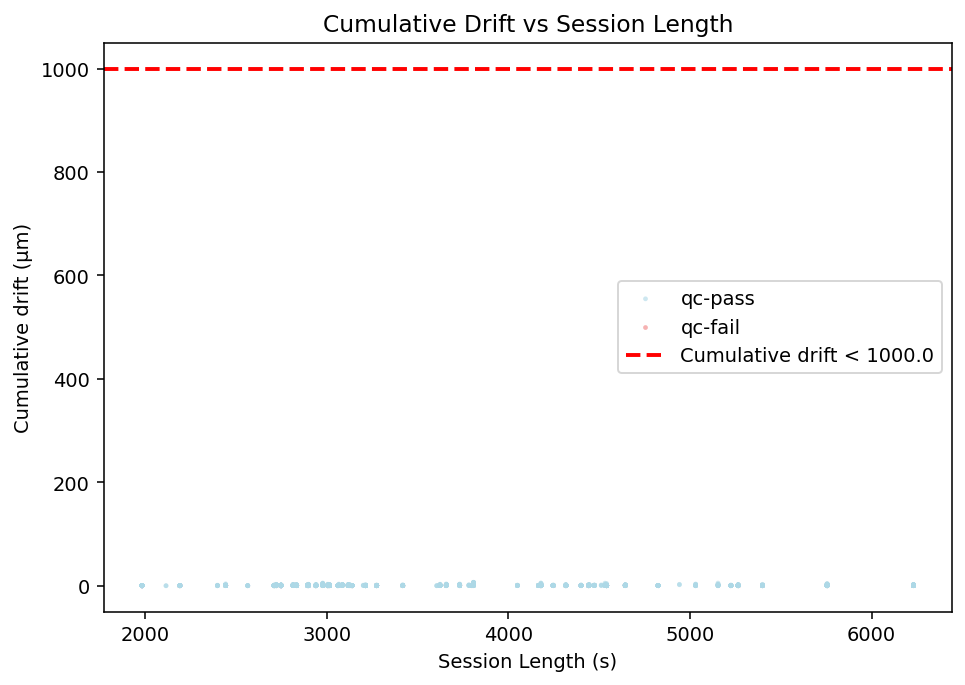

In [23]:
x = df["length"]
y = df["cumulative_drift"]

# Define QC mask
df['qc_pass_cumulative_drift'] = (
    (df['firing_rate'] > qc_thresholds["firing_rate"][1]) &
    (df['cumulative_drift'] < qc_thresholds_secondary["cumulative_drift"][1])
)
qc_pass_cumulative_drift = df['qc_pass_cumulative_drift']

mask = ~(np.isnan(x.values) | np.isnan(y.values))
xclean = x.values[mask]
yclean = y.values[mask]
qc_clean = qc_pass_cumulative_drift.values[mask]

plt.figure(figsize=(7, 5), dpi=140)
plt.scatter(xclean[qc_clean], yclean[qc_clean], alpha=0.6, s=6, color='lightblue', label='qc-pass', edgecolor='none')
plt.scatter(xclean[~qc_clean], yclean[~qc_clean], alpha=0.6, s=6, color='lightcoral', label='qc-fail', edgecolor='none')

fr_thresh = qc_thresholds["firing_rate"][1]
drift_thresh = qc_thresholds_secondary["cumulative_drift"][1]
plt.axhline(drift_thresh, color='red', linestyle='--', linewidth=2, label=f'Cumulative drift < {drift_thresh}')

plt.title("Cumulative Drift vs Session Length")
plt.xlabel("Session Length (s)")
plt.ylabel("Cumulative drift (µm)")
plt.legend()
plt.tight_layout()
plt.savefig(qc_dir / "scat_session_length_vs_cumudrift.png", bbox_inches="tight")

In [24]:
# ---- 7) Save a per-unit pass/fail export for your records/slides ----
pass_cols = ["qc_pass_all"] + [col for col in df.columns if col.startswith("qc_pass_")]
export_cols = [
    "session_id", "datetime", "mouse", "region", "insertion_number",
    "unit_id", "firing_rate", "snr", "presence_ratio", "isi_violation",
    "amplitude_cutoff", "isolation_distance", "contamination_rate", "max_drift",
    "manual_label"
] + pass_cols

units_qc = df[export_cols].copy()
per_unit_path = p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv"
units_qc.to_csv(per_unit_path, index=False)